# Classificatore CNN per VLP Waveforms

Addestra un classificatore supervisionato (1D CNN) per distinguere
VLP type1 da type2.

## Pipeline
1. Carica i due dataset type1 e type2
2. Split train/val/test (80/10/10)
3. Addestra CNN 1D per 50 epochs (con grafico in tempo reale)
4. Valuta: accuracy, AUC, confusion matrix, ROC curve
5. Predici su waveform reali

In [1]:
from pathlib import Path
import sys
import os

# Find project root (where src/ lives)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150


# Setup device: MPS (Apple Silicon GPU) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using GPU: MPS (Apple Silicon)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using GPU: CUDA')
else:
    device = torch.device('cpu')
    print('Using CPU')
import src.classifier as classifier_module
classifier_module = importlib.reload(classifier_module)
print('Modules loaded OK')
print('Project root: %s' % PROJECT_ROOT)

Modules loaded OK
Project root: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER


## 1. Carica dati

In [2]:
TYPE1_PATH = PROJECT_ROOT / 'data/processed/Waveforms_type1_extended_128samples.txt'
TYPE2_PATH = PROJECT_ROOT / 'data/processed/Waveforms_type2_extended_128samples.txt'

train_loader, val_loader, test_loader = classifier_module.load_and_split(
    TYPE1_PATH, TYPE2_PATH, waveform_length=128, seed=42
)

n_train = len(train_loader.dataset)
n_val = len(val_loader.dataset)
n_test = len(test_loader.dataset)
print('Train: %d waveforms' % n_train)
print('Val:   %d waveforms' % n_val)
print('Test:  %d waveforms' % n_test)

train_y = train_loader.dataset.labels
print('')
print('Train class distribution:')
print('  Type1 (0): %d' % int((train_y == 0).sum()))
print('  Type2 (1): %d' % int((train_y == 1).sum()))

  Type1: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/data/processed/Waveforms_type1_extended_128samples.txt
  Type2: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/data/processed/Waveforms_type2_extended_128samples.txt
Train: 7444 waveforms
Val:   930 waveforms
Test:  932 waveforms

Train class distribution:
  Type1 (0): 4304
  Type2 (1): 3140


## 2. Addestra CNN (grafico in tempo reale)

Device: cpu


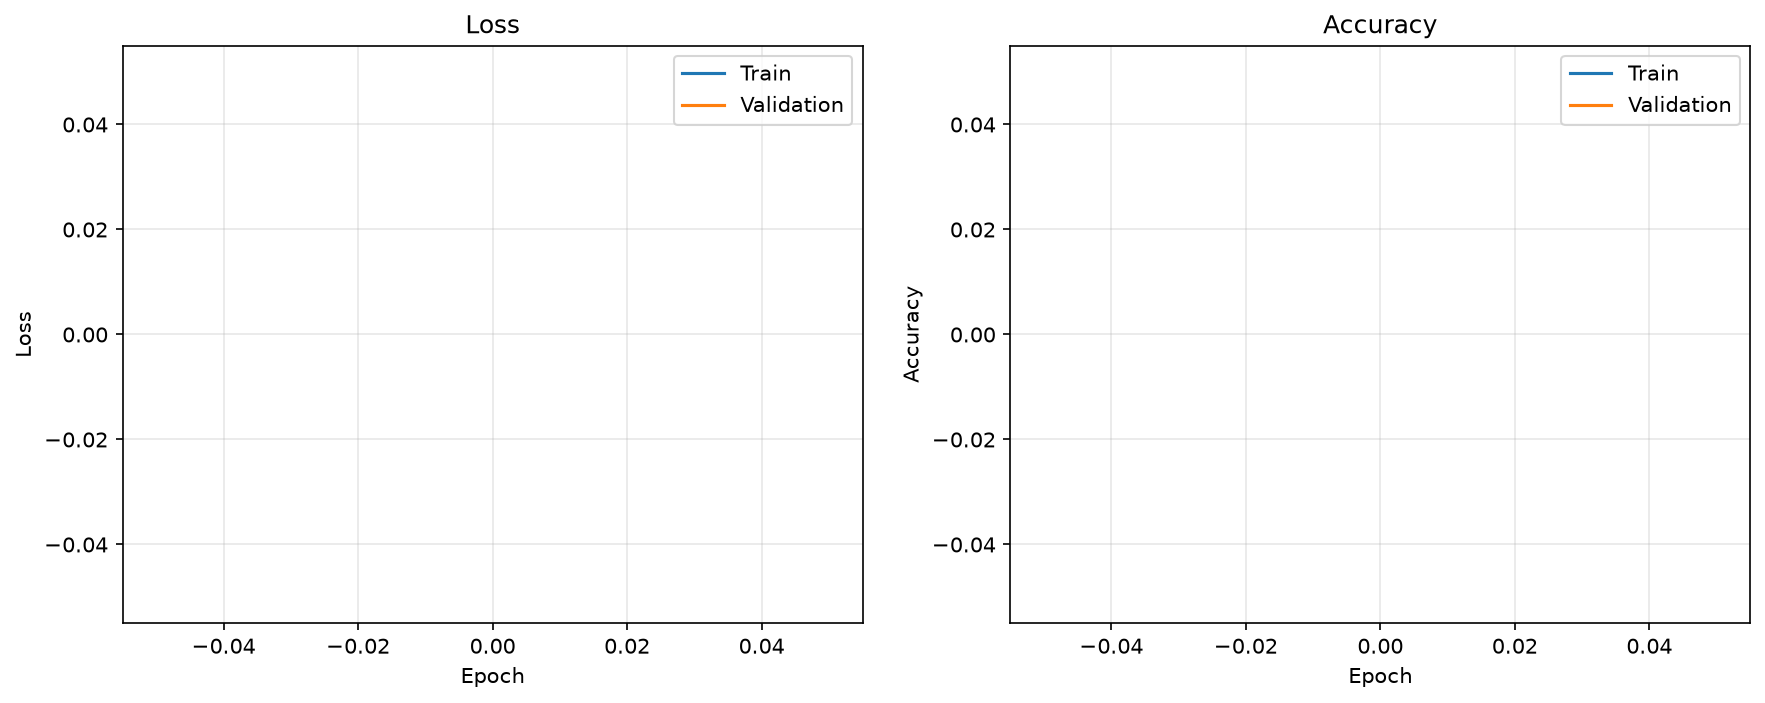

Epoch   1/5 | train_loss=0.2210 train_acc=0.9034 | val_loss=0.0690 val_acc=0.9731 | best=0.9731 (epoch 1)
Epoch   5/5 | train_loss=0.0581 train_acc=0.9780 | val_loss=0.0497 val_acc=0.9785 | best=0.9892 (epoch 4)
Model saved to /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/cnn_classifier.pt


In [ ]:
# device gia' definito nella cella di setup
print('Device: %s' % device)

# plot=True mostra il grafico in tempo reale durante l'addestramento
model, history = classifier_module.train_classifier(
    train_loader,
    val_loader,
    epochs=50,
    learning_rate=1e-3,
    device=device,
    save_path=str(PROJECT_ROOT / 'outputs/cnn_classifier.pt'),
    plot=False,
)


## 3. Valuta sul test set

In [4]:
results = classifier_module.evaluate_model(model, test_loader, device=device)
print('')
print('Accuracy: %.4f' % results['accuracy'])
print('AUC:      %.4f' % results['auc'])

# Also show classification report from results
from sklearn.metrics import classification_report
target_names = ['Type1', 'Type2']
print('')
print(classification_report(results['labels'], results['predictions'], target_names=target_names))


Test Accuracy: 0.9732
Test AUC: 0.9977

Classification Report:
              precision    recall  f1-score   support

       Type1       0.99      0.96      0.98       532
       Type2       0.95      0.99      0.97       400

    accuracy                           0.97       932
   macro avg       0.97      0.98      0.97       932
weighted avg       0.97      0.97      0.97       932

Confusion Matrix:
[[510  22]
 [  3 397]]

Accuracy: 0.9732
AUC:      0.9977

              precision    recall  f1-score   support

       Type1       0.99      0.96      0.98       532
       Type2       0.95      0.99      0.97       400

    accuracy                           0.97       932
   macro avg       0.97      0.98      0.97       932
weighted avg       0.97      0.97      0.97       932



## 4. Plots (interattivi)

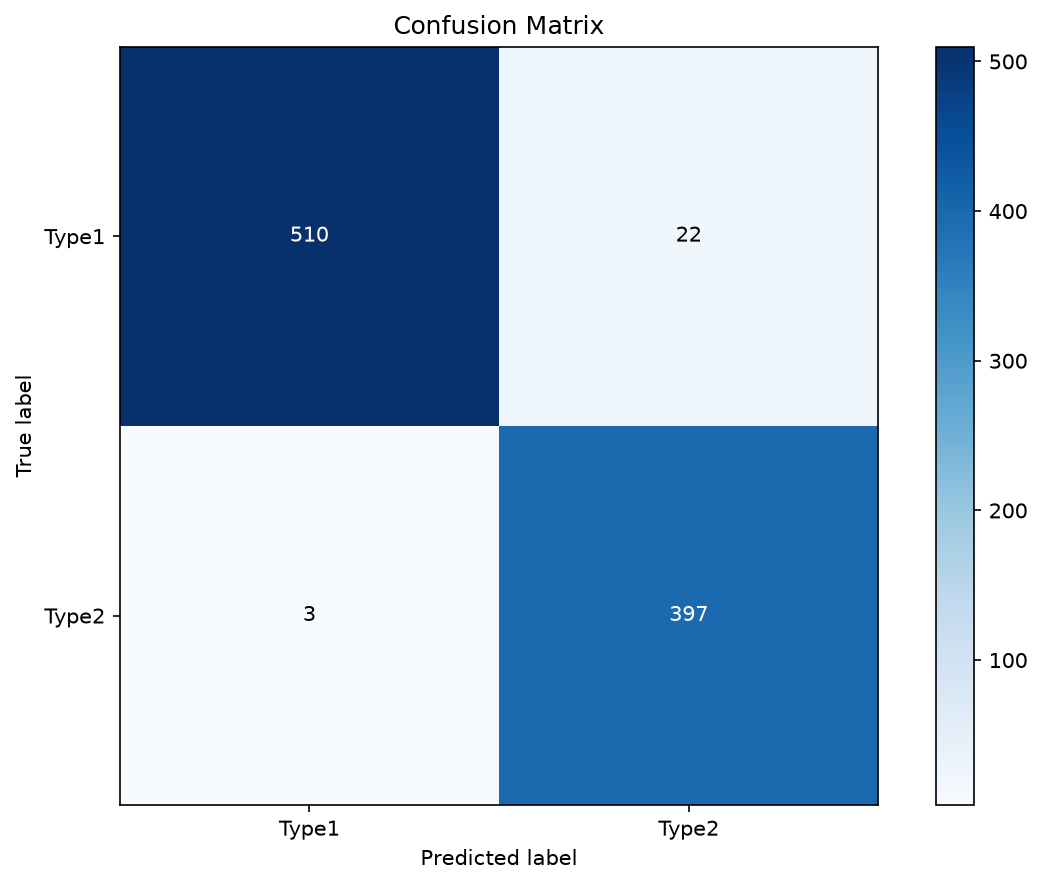

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
classifier_module.plot_confusion_matrix(results['confusion_matrix'], ax=ax)
plt.tight_layout()
plt.show()

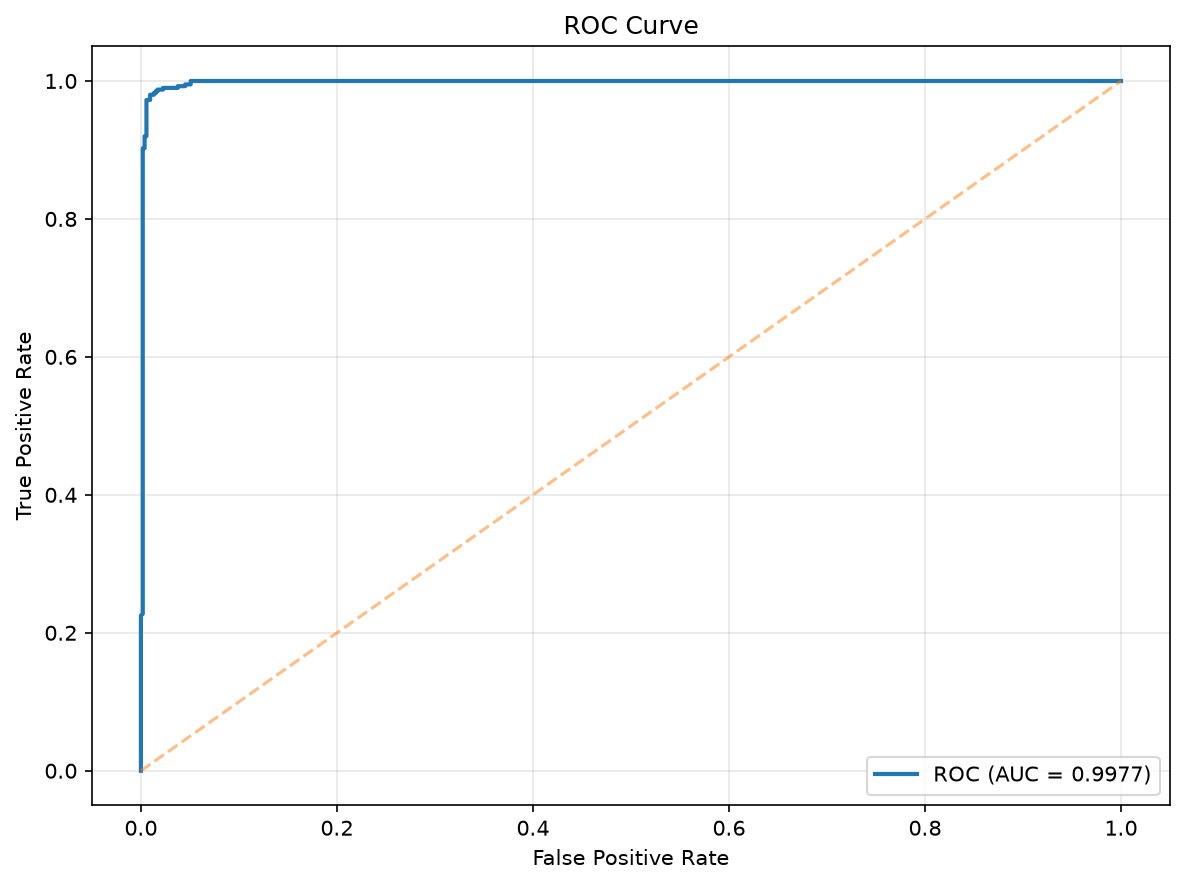

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
classifier_module.plot_roc_curve(results['labels'], results['probabilities'], ax=ax)
plt.tight_layout()
plt.show()

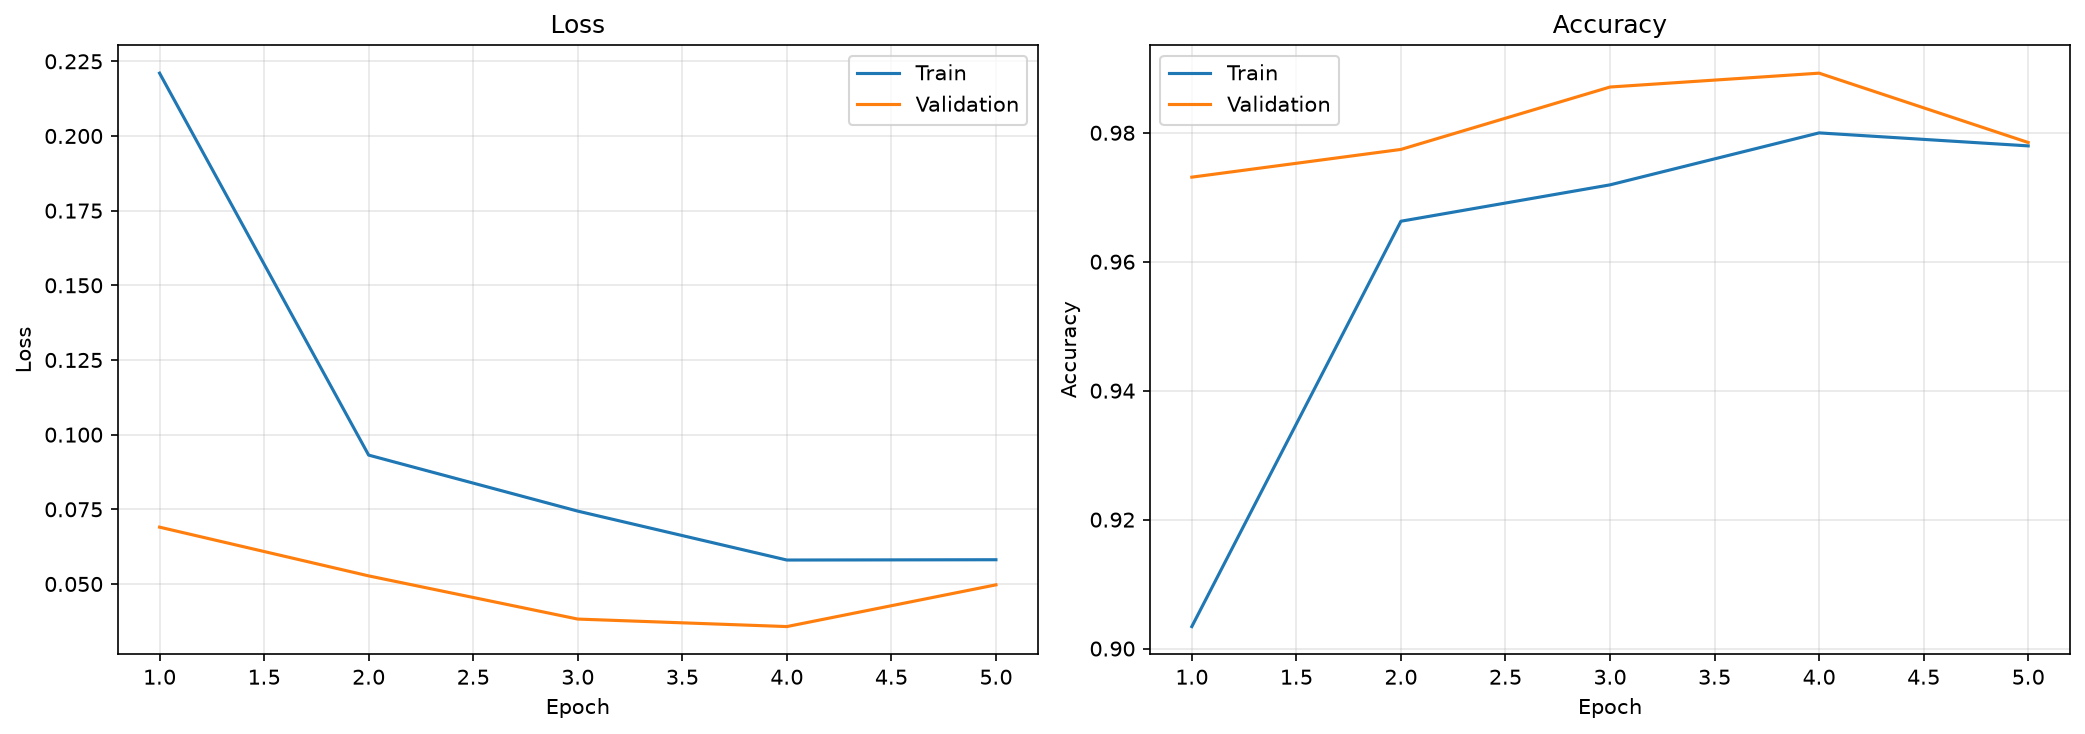

In [7]:
# Plot training history (statico, dopo l'addestramento)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
epochs = list(range(1, len(history.train_loss) + 1))
axes[0].plot(epochs, history.train_loss, label='Train', linewidth=1.5)
axes[0].plot(epochs, history.val_loss, label='Validation', linewidth=1.5)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history.train_acc, label='Train', linewidth=1.5)
axes[1].plot(epochs, history.val_acc, label='Validation', linewidth=1.5)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Predici su waveform reali (prime 20)

First 20 real waveforms predictions:
  [  0] Type1=0.002  Type2=0.998  -> Type2
  [  1] Type1=0.000  Type2=1.000  -> Type2
  [  2] Type1=0.000  Type2=1.000  -> Type2
  [  3] Type1=0.000  Type2=1.000  -> Type2
  [  4] Type1=0.000  Type2=1.000  -> Type2
  [  5] Type1=0.000  Type2=1.000  -> Type2
  [  6] Type1=0.000  Type2=1.000  -> Type2
  [  7] Type1=0.000  Type2=1.000  -> Type2
  [  8] Type1=0.000  Type2=1.000  -> Type2
  [  9] Type1=0.000  Type2=1.000  -> Type2
  [ 10] Type1=0.000  Type2=1.000  -> Type2
  [ 11] Type1=0.003  Type2=0.997  -> Type2
  [ 12] Type1=0.000  Type2=1.000  -> Type2
  [ 13] Type1=0.000  Type2=1.000  -> Type2
  [ 14] Type1=0.000  Type2=1.000  -> Type2
  [ 15] Type1=0.000  Type2=1.000  -> Type2
  [ 16] Type1=0.000  Type2=1.000  -> Type2
  [ 17] Type1=0.000  Type2=1.000  -> Type2
  [ 18] Type1=0.000  Type2=1.000  -> Type2
  [ 19] Type1=0.000  Type2=1.000  -> Type2


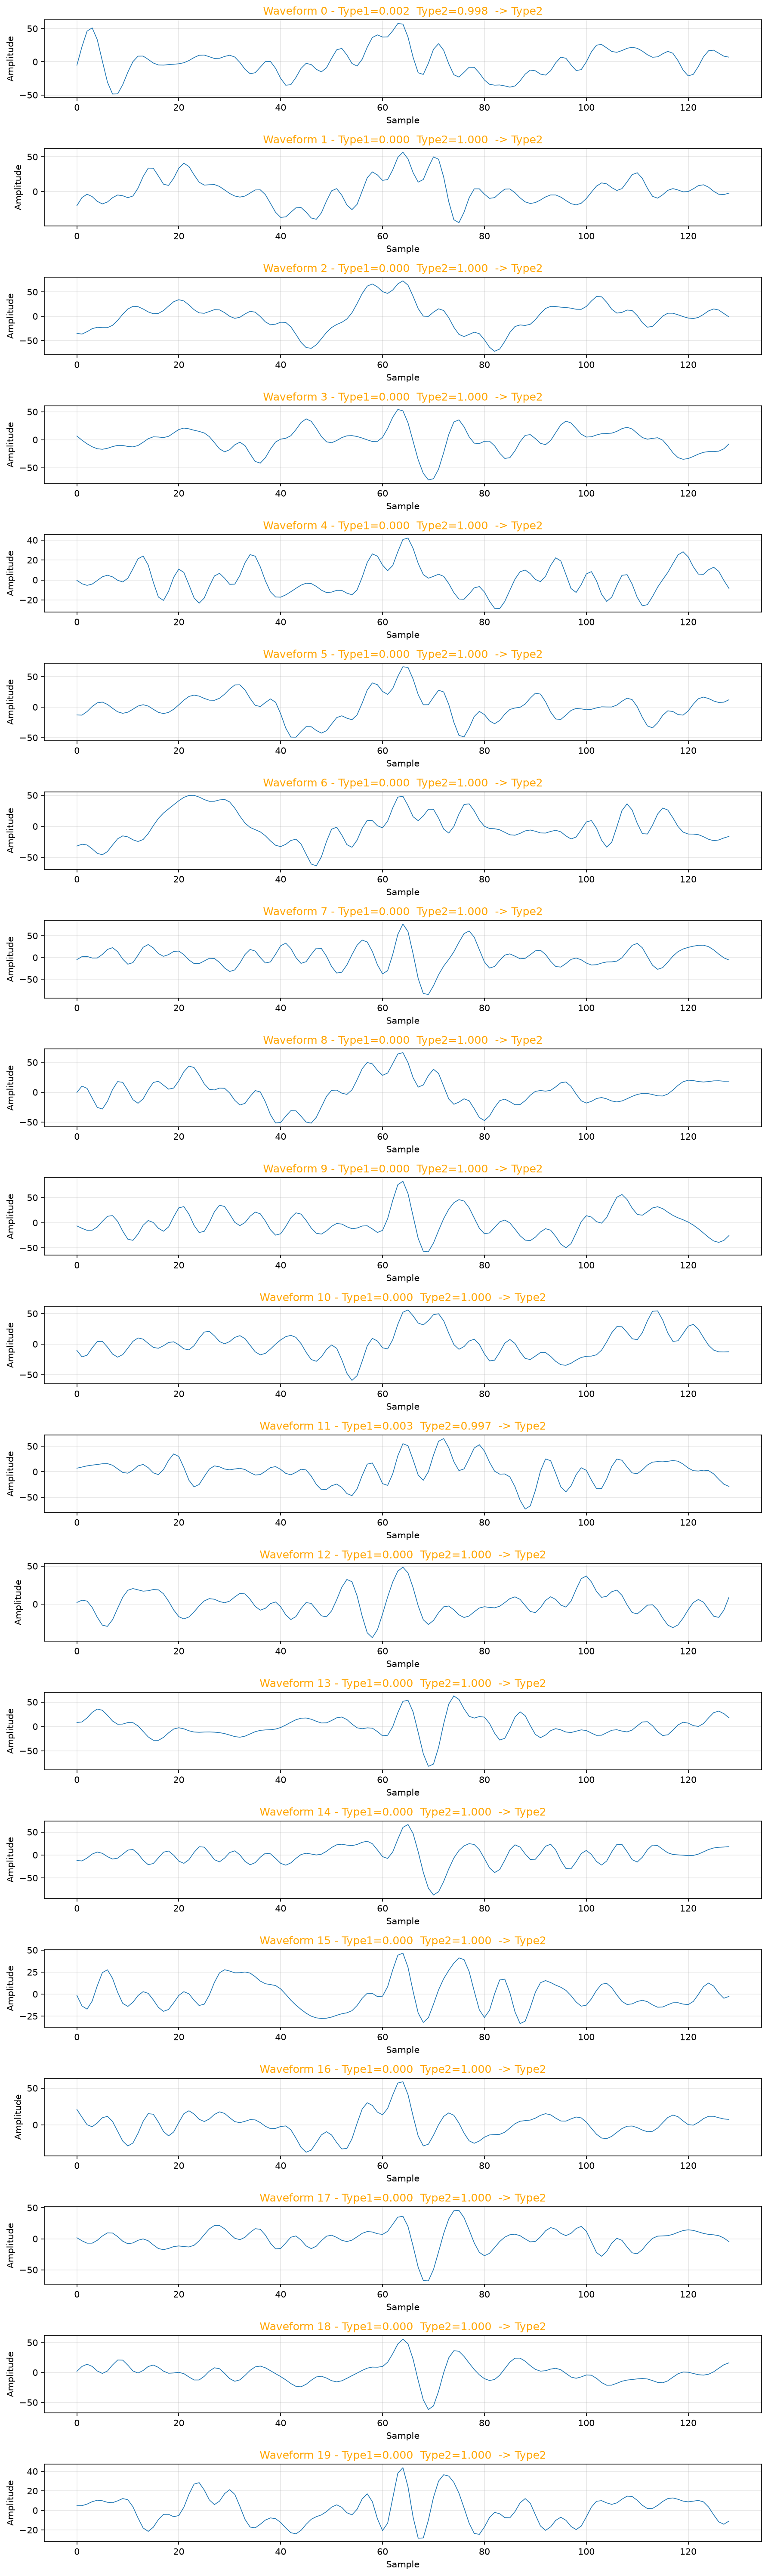

In [8]:
real_path = PROJECT_ROOT / 'data/measured/VLPs-2019_low-pass.dat'
real_data = np.loadtxt(real_path, dtype=np.float32)

# Center-crop to 128
target_len = 128
current_len = real_data.shape[1] if real_data.ndim == 2 else len(real_data)
if current_len > target_len:
    excess = current_len - target_len
    left = excess // 2
    real_data = real_data[:, left : current_len - left]
elif current_len < target_len:
    deficit = target_len - current_len
    left = deficit // 2
    real_data = np.pad(real_data, ((0, 0), (left, deficit - left)), mode='constant')

# Normalize with same stats as training
all_train = train_loader.dataset.waveforms
global_mean = float(all_train.mean())
global_std = float(all_train.std()) + 1e-8
real_data = (real_data - global_mean) / global_std

# Predict first 20 waveforms
n_show = min(20, len(real_data))
preds = classifier_module.predict(model, real_data[:n_show], device=device)

print('First 20 real waveforms predictions:')
for i in range(n_show):
    p1 = float(preds['prob_type1'][i])
    p2 = float(preds['prob_type2'][i])
    pred_label = 'Type2' if preds['predictions'][i] == 1 else 'Type1'
    print('  [%3d] Type1=%.3f  Type2=%.3f  -> %s' % (i, p1, p2, pred_label))

# Plot them
fig, axes = plt.subplots(n_show, 1, figsize=(12, 2 * n_show))
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(real_data[i], linewidth=0.8)
    p1 = float(preds['prob_type1'][i])
    p2 = float(preds['prob_type2'][i])
    pred_label = 'Type2' if preds['predictions'][i] == 1 else 'Type1'
    color = 'blue' if preds['predictions'][i] == 0 else 'orange'
    ax.set_title('Waveform %d - Type1=%.3f  Type2=%.3f  -> %s' % (i, p1, p2, pred_label), color=color)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Predici su TUTTE le waveform reali

In [9]:
# ============================================
# PREDIZIONE SU TUTTE LE WAVEFORM REALI
# ============================================

# Carica dati reali se non già caricati
if 'real_data' not in locals():
    print('Loading real data...')
    real_path = PROJECT_ROOT / 'data/measured/VLPs-2019_low-pass.dat'
    real_data = np.loadtxt(real_path, dtype=np.float32)
    target_len = 128
    current_len = real_data.shape[1] if real_data.ndim == 2 else len(real_data)
    if current_len > target_len:
        excess = current_len - target_len
        left = excess // 2
        real_data = real_data[:, left : current_len - left]
    elif current_len < target_len:
        deficit = target_len - current_len
        left = deficit // 2
        real_data = np.pad(real_data, ((0, 0), (left, deficit - left)), mode='constant')
    all_train = train_loader.dataset.waveforms
    global_mean = float(all_train.mean())
    global_std = float(all_train.std()) + 1e-8
    real_data = (real_data - global_mean) / global_std
    print('Real data loaded: %d waveforms' % len(real_data))

print('Predicting on all %d waveforms...' % len(real_data))
all_preds = classifier_module.predict(model, real_data, device=device)

# Summary
n_type1 = int((all_preds['predictions'] == 0).sum())
n_type2 = int((all_preds['predictions'] == 1).sum())
n_uncertain = int(((all_preds['prob_type1'] > 0.3) & (all_preds['prob_type2'] > 0.3)).sum())

print('')
print('Summary:')
print('  Total waveforms: %d' % len(real_data))
print('  Predicted Type1: %d (%.1f%%)' % (n_type1, 100.0 * n_type1 / len(real_data)))
print('  Predicted Type2: %d (%.1f%%)' % (n_type2, 100.0 * n_type2 / len(real_data)))
print('  Uncertain (both > 0.3): %d (%.1f%%)' % (n_uncertain, 100.0 * n_uncertain / len(real_data)))
print('  Mean prob Type1: %.4f' % float(all_preds['prob_type1'].mean()))
print('  Mean prob Type2: %.4f' % float(all_preds['prob_type2'].mean()))

# ============================================
# GRAFICO INTERATTIVO CON PLOTLY
# ============================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

x = np.arange(len(real_data))
y = np.zeros(len(real_data))
classes = []
confidences = []
colors = []
sizes = []

for i in range(len(real_data)):
    p1 = float(all_preds['prob_type1'][i])
    p2 = float(all_preds['prob_type2'][i])
    conf = abs(p1 - p2)  # confidenza = differenza tra le due probabilità
    if all_preds['predictions'][i] == 0:
        y[i] = p1
        classes.append('Type1')
        colors.append('blue')
    else:
        y[i] = p2
        classes.append('Type2')
        colors.append('orange')
    confidences.append(conf)
    sizes.append(5 + conf * 15)  # dimensione proporzionale alla confidenza

# Crea subplot con 2 pannelli: overview + zoom
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.3, 0.7],
    vertical_spacing=0.05,
    subplot_titles=('Overview (tutte le waveform)', 'Dettaglio (zoom su una zona)'),
)

# Panel 1: Overview - tutti i punti
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode='markers',
        marker=dict(
            color=colors,
            size=6,
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey')
        ),
        text=['%s (conf=%.2f)' % (c, conf) for c, conf in zip(classes, confidences)],
        hoverinfo='text',
        name='All waveforms',
        showlegend=False
    ),
    row=1, col=1
)

# Panel 2: Zoom su una zona (es. primi 1000)
zoom_n = min(1000, len(real_data))
x_zoom = x[:zoom_n]
y_zoom = y[:zoom_n]
colors_zoom = colors[:zoom_n]
conf_zoom = confidences[:zoom_n]
classes_zoom = classes[:zoom_n]

fig.add_trace(
    go.Scatter(
        x=x_zoom,
        y=y_zoom,
        mode='markers',
        marker=dict(
            color=colors_zoom,
            size=sizes[:zoom_n],
            opacity=0.8,
            line=dict(width=0.5, color='DarkSlateGrey')
        ),
        text=['%s (conf=%.2f)' % (c, conf) for c, conf in zip(classes_zoom, conf_zoom)],
        hoverinfo='text',
        name='Zoomed',
        showlegend=False
    ),
    row=2, col=1
)

# Linea di riferimento a 0.5
fig.add_hline(y=0.5, line_dash='dash', line_color='red', opacity=0.3, row=1, col=1)
fig.add_hline(y=0.5, line_dash='dash', line_color='red', opacity=0.3, row=2, col=1)

# Layout
fig.update_layout(
    height=900,
    title_text='Classificazione VLP Waveforms - Class 1 vs Class 2',
    title_font_size=16,
    hovermode='x unified',
    plot_bgcolor='white',
    margin=dict(l=60, r=30, t=60, b=30)
)

# Y-axis limitata a [0.5, 1.0]
fig.update_yaxes(range=[0.7, 1.0], title_text='Confidenza classe predetta', row=1, col=1)
fig.update_yaxes(range=[0.7, 1.0], title_text='Confidenza classe predetta (zoom)', row=2, col=1)

# X-axis
fig.update_xaxes(title_text='Waveform index', row=2, col=1, rangeslider=dict(visible=True))
fig.update_xaxes(title_text='Waveform index', row=1, col=1)

# Mostra
fig.show()

print('\nGrafico Plotly generato!')
print('  - Scroll per zoomare')
print('  - Trascina per spostarti')
print('  - Clicca e trascina per zoomare su una selezione')
print('  - Hover per vedere confidenza di ogni punto')
print('  - Barra in basso per navigare rapidamente')
print('  - Doppio click per resettare lo zoom')
